In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , accuracy_score , f1_score , classification_report
from sklearn.model_selection import GridSearchCV



In [2]:
path = kagglehub.dataset_download("sinadehestani/wine-quality-red-and-white")
print(path)

Using Colab cache for faster access to the 'wine-quality-red-and-white' dataset.
/kaggle/input/wine-quality-red-and-white


In [3]:
df = pd.read_csv(f"{path}/wine_quality_merged.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [4]:
df.shape

(6497, 13)

In [5]:
df.nunique(axis = 0)

,0
fixed acidity,106
volatile acidity,187
citric acid,89
residual sugar,316
chlorides,214
free sulfur dioxide,135
total sulfur dioxide,276
density,998
pH,108
sulphates,111


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [7]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [8]:
df.type.value_counts()

,count
type,
white,4898
red,1599


In [9]:
df.quality.value_counts()

,count
quality,
6,2836
5,2138
7,1079
4,216
8,193
3,30
9,5


In [10]:
df.duplicated().sum()

np.int64(1177)

In [11]:
duplicates = df[df.duplicated(keep = False)]
duplicates.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,red
11,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,red
22,7.9,0.43,0.21,1.6,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5,red


In [12]:
df_clean = df.drop_duplicates(keep = 'first').reset_index(drop = True)
df_clean.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red


In [13]:
# After deleting duplicates,the change in shape
print(df.shape)
print(df_clean.shape)

(6497, 13)
(5320, 13)


In [14]:
df = df_clean

In [15]:
df.shape

(5320, 13)

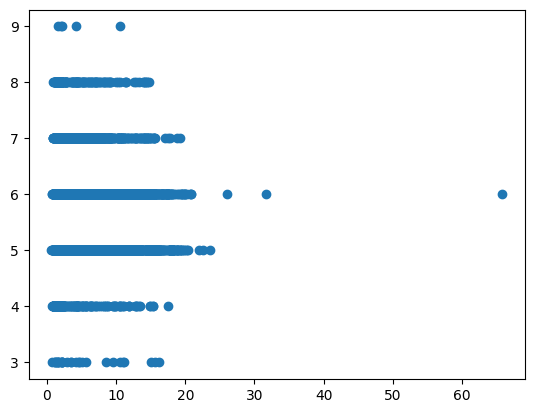

In [16]:
plt.scatter(df['residual sugar'], df.quality)
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [19]:
corr_with_quality = df.corr()['quality'].drop('quality')
top_10 = corr_with_quality.abs().sort_values(ascending = False).head(10)
top_10


,quality
alcohol,0.469422
density,0.326434
volatile acidity,0.265205
chlorides,0.202137
type,0.114809
citric acid,0.097954
fixed acidity,0.080092
residual sugar,0.056830
free sulfur dioxide,0.054002
total sulfur dioxide,0.050296


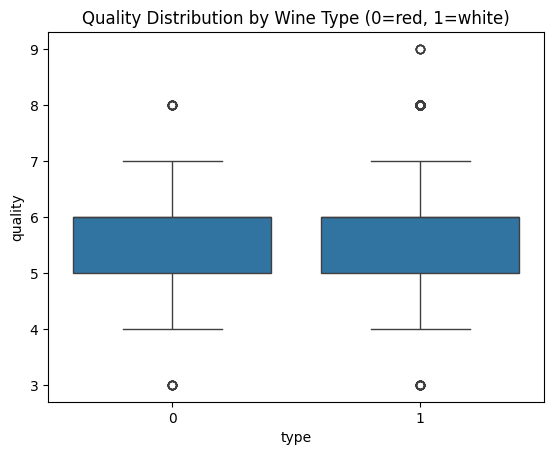

In [20]:
sns.boxplot(data=df, x='type', y='quality')
plt.title('Quality Distribution by Wine Type (0=red, 1=white)')
plt.show()

In [21]:
X = df_clean.drop('quality',axis = 1)
y = df_clean['quality']

In [22]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0


In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 2 , stratify = y)

In [24]:
#using standardScaler
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
X_train_scaled1 = standard_scaler.fit_transform(X_train)
X_test_scaled1 = standard_scaler.transform(X_test)


In [25]:
#using MinMax Scaler
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler()
X_train_scaled2 = min_max_scaler.fit_transform(X_train)
X_test_scaled2 = min_max_scaler.transform(X_test)

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': list(range(1,100,5)), 'metric': ['euclidean'], 'weights': ['uniform', 'distance'],
    'n_neighbors': list(range(1,100,5)), 'metric': ['manhattan'], 'weights': ['uniform', 'distance'],
    'n_neighbors': list(range(1,100,5)), 'metric': ['minkowski'], 'p': [3], 'weights': ['uniform', 'distance']

}

KNN = KNeighborsClassifier()

# without Scaling
grid_no_scaling = GridSearchCV(KNN, param_grid,scoring = 'f1_macro' ,  cv=5 )
grid_no_scaling.fit(X_train, y_train)

# MinMax Scaling
grid_minmax_scaling = GridSearchCV(KNN, param_grid,scoring = 'f1_macro', cv=5)
grid_minmax_scaling.fit(X_train_scaled2, y_train)

# Standard Scaling

grid_standard_scaling = GridSearchCV(KNN, param_grid,scoring = 'f1_macro', cv=5)
grid_standard_scaling.fit(X_train_scaled1, y_train)



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['minkowski'],
                         'n_neighbors': [1, 6, 11, 16, 21, 26, 31, 36, 41, 46,
                                         51, 56, 61, 66, 71, 76, 81, 86, 91,
                                         96],
                         'p': [3], 'weights': ['uniform', 'distance']},
             scoring='f1_macro')

In [34]:
print("without scaling : Best Parameters" , grid_no_scaling.best_params_ , "best f1_macro score : " , grid_no_scaling.best_score_)
print("MinMax Scaling : Best Parameters" , grid_minmax_scaling.best_params_ , "best f1_macro  score : "   , grid_minmax_scaling.best_score_)
print("Standard Scaling : Best Parameters" , grid_standard_scaling.best_params_ ,  "best f1_macro  score : " , grid_standard_scaling.best_score_)

without scaling : Best Parameters {'metric': 'minkowski', 'n_neighbors': 1, 'p': 3, 'weights': 'uniform'} best f1_macro score :  0.2037327040147227
MinMax Scaling : Best Parameters {'metric': 'minkowski', 'n_neighbors': 6, 'p': 3, 'weights': 'distance'} best f1_macro  score :  0.26567936424696237
Standard Scaling : Best Parameters {'metric': 'minkowski', 'n_neighbors': 6, 'p': 3, 'weights': 'distance'} best f1_macro  score :  0.2688764289644387


In [35]:
def accuracy_and_f1score_vs_k(X_train, X_test, y_train, y_test, k_values, metric, weights):
    accs = []
    f1_scores = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        accs.append(accuracy_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred, average='macro'))
    return accs, f1_scores

k_values = list(range(1, 100, 5))



acc_ns, f1_ns = accuracy_and_f1score_vs_k(X_train, X_test, y_train, y_test, k_values, 'minkowski', 'uniform')
acc_mm, f1_mm = accuracy_and_f1score_vs_k(X_train_scaled2, X_test_scaled2, y_train, y_test, k_values, 'minkowski', 'distance')
acc_std, f1_std = accuracy_and_f1score_vs_k(X_train_scaled1, X_test_scaled1, y_train, y_test, k_values, 'minkowski', 'uniform')

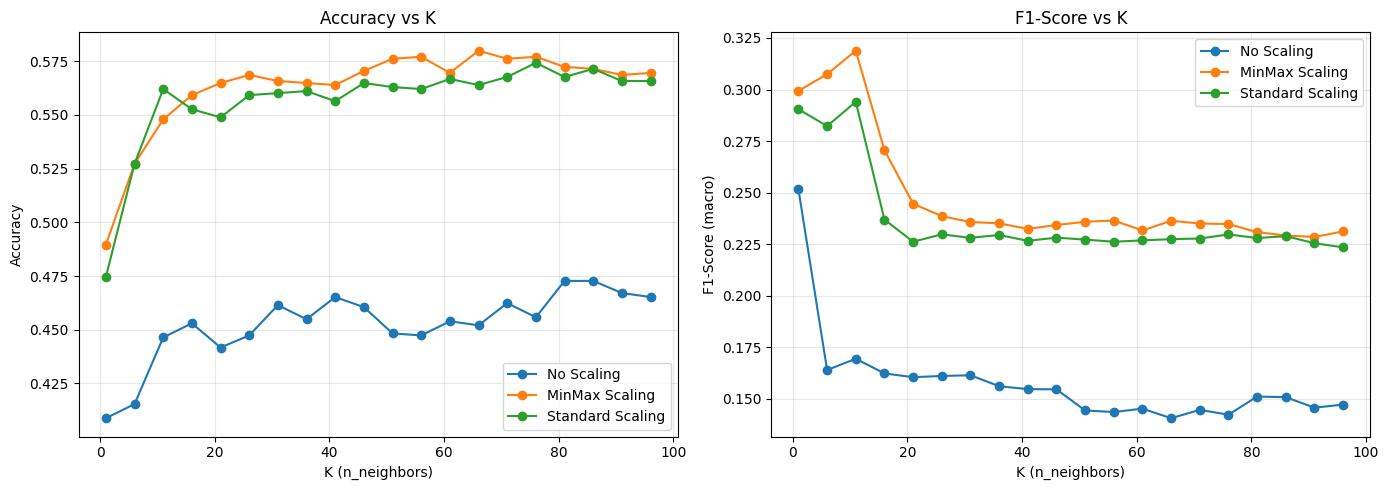

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, acc_ns, marker='o', label='No Scaling')
axes[0].plot(k_values, acc_mm, marker='o', label='MinMax Scaling')
axes[0].plot(k_values, acc_std, marker='o', label='Standard Scaling')
axes[0].set_xlabel('K (n_neighbors)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs K')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(k_values, f1_ns, marker='o', label='No Scaling')
axes[1].plot(k_values, f1_mm, marker='o', label='MinMax Scaling')
axes[1].plot(k_values, f1_std, marker='o', label='Standard Scaling')
axes[1].set_xlabel('K (n_neighbors)')
axes[1].set_ylabel('F1-Score (macro)')
axes[1].set_title('F1-Score vs K')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()